In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [3]:
input_path = f"/Users/athmiha/Desktop/final report/xgb_test_preds_final.csv"

df_test = pd.read_csv(input_path)
display(df_test.head(10))
print(df_test.shape)

input_path_2 = f"/Users/athmiha/Desktop/final report/xgb_val_preds_final.csv"

df_val = pd.read_csv(input_path_2)
display(df_val.head(10))
print(df_val.shape)

,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-26 00:20:00,9,0,7.677720,-0.015234,1.322280,0.015234
1,2025-09-26 00:20:00,75,91,72.974430,98.665540,2.025574,-7.665543
2,2025-09-26 00:20:00,14,0,15.621967,-0.016490,-1.621967,0.016490
3,2025-09-26 00:20:00,81,1,90.493940,3.343476,-9.493942,-2.343476
4,2025-09-26 00:20:00,152,0,143.637150,-0.047299,8.362854,0.047299
5,2025-09-26 00:20:00,120,0,170.612840,-0.041982,-50.612839,0.041982
6,2025-09-26 00:20:00,133,50,103.899530,49.113773,29.100471,0.886227
7,2025-09-26 00:20:00,7,0,2.905754,-0.015234,4.094246,0.015234
8,2025-09-26 00:20:00,169,0,166.568480,0.034520,2.431519,-0.034520
9,2025-09-26 00:20:00,199,0,211.816530,0.067824,-12.816528,-0.067824


(58968, 7)


,start_interval,entries,excluded_roadway_entries,predicted_entries,predicted_excluded_roadway_entries,entries_residual,excluded_roadway_entries_residual
0,2025-09-15 19:50:00,205,0,207.387820,-0.160143,-2.387817,0.160143
1,2025-09-15 19:50:00,216,0,213.971620,0.047544,2.028381,-0.047544
2,2025-09-15 19:50:00,258,0,247.159270,-0.075408,10.840729,0.075408
3,2025-09-15 19:50:00,269,210,264.963900,213.123690,4.036102,-3.123688
4,2025-09-15 19:50:00,329,0,319.018500,-0.015529,9.981506,0.015529
5,2025-09-15 19:50:00,339,37,333.347020,33.079018,5.652985,3.920982
6,2025-09-15 19:50:00,351,0,351.393700,-0.226388,-0.393707,0.226388
7,2025-09-15 19:50:00,425,0,391.218170,0.101352,33.781830,-0.101352
8,2025-09-15 19:50:00,11,2,12.657825,0.992276,-1.657825,1.007724
9,2025-09-15 19:50:00,164,42,169.873050,42.719753,-5.873047,-0.719753


(58968, 7)


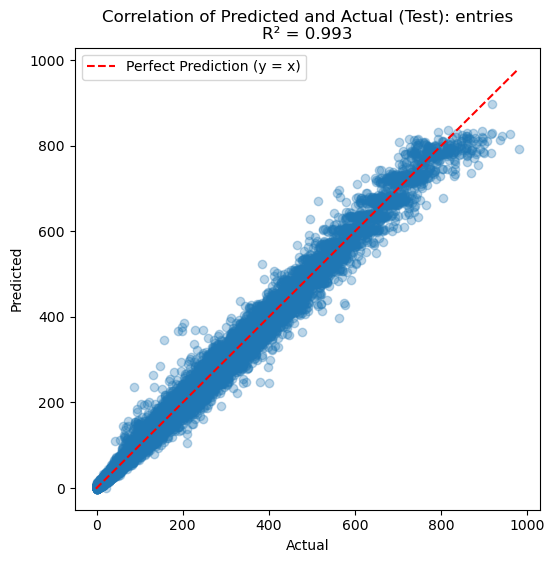

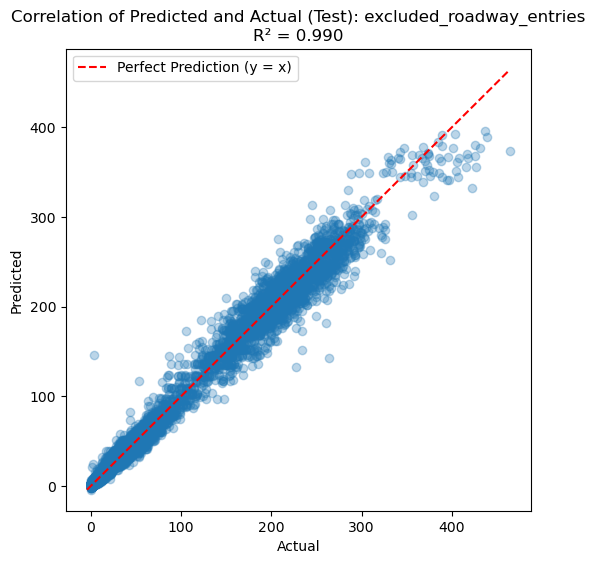

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/xgb_test_preds_final.csv"
df_preds = pd.read_csv(input_path)

# Target and predicted columns
target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]

# Plot correlation for each target
for col, pred_col in zip(target_cols, pred_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(df_preds[col], df_preds[pred_col], alpha=0.3)

    # Plot y = x line
    min_val = min(df_preds[col].min(), df_preds[pred_col].min())
    max_val = max(df_preds[col].max(), df_preds[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction (y = x)")

    # Compute R²
    r2_val = r2_score(df_preds[col], df_preds[pred_col])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Correlation of Predicted and Actual (Test): {col}\nR² = {r2_val:.3f}")
    plt.legend()
    plt.show()


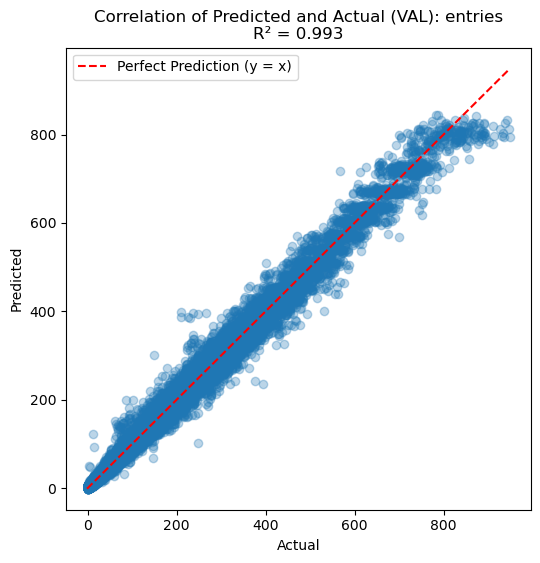

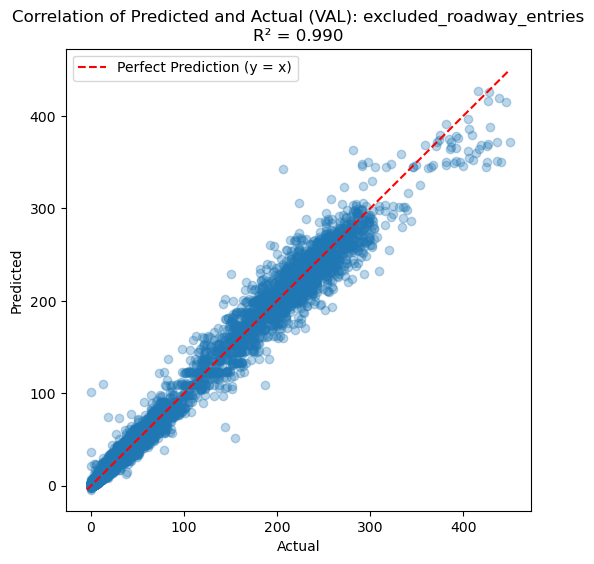

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/xgb_val_preds_final.csv"
df_preds = pd.read_csv(input_path)

target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]


for col, pred_col in zip(target_cols, pred_cols):
    plt.figure(figsize=(6, 6))
    plt.scatter(df_preds[col], df_preds[pred_col], alpha=0.3)

    # Plot y = x line
    min_val = min(df_preds[col].min(), df_preds[pred_col].min())
    max_val = max(df_preds[col].max(), df_preds[pred_col].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction (y = x)")

    # Compute R²
    r2_val = r2_score(df_preds[col], df_preds[pred_col])

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Correlation of Predicted and Actual (VAL): {col}\nR² = {r2_val:.3f}")
    plt.legend()
    plt.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

# --- Load CSV ---
input_path = "/Users/athmiha/Desktop/final report/xgb_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

# Ensure datetime format
df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

# Group by time and sum values
entries_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["entries", "predicted_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

# Create plot
fig = go.Figure()

# Actual 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["entries"],
    mode="lines+markers",
    name="Actual Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["predicted_entries"],
    mode="lines+markers",
    name="Predicted Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Entries Over Time (Test Set)",
    xaxis_title="Start Interval",
    yaxis_title="Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go


input_path = "/Users/athmiha/Desktop/final report/xgb_val_preds_final.csv"
df_test_preds = pd.read_csv(input_path)


df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

entries_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["entries", "predicted_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

# plot
fig = go.Figure()

# Actual 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["entries"],
    mode="lines+markers",
    name="Actual Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted 
fig.add_trace(go.Scatter(
    x=entries_time_test["start_interval"],
    y=entries_time_test["predicted_entries"],
    mode="lines+markers",
    name="Predicted Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Entries Over Time (Val Set)",
    xaxis_title="Start Interval",
    yaxis_title="Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go

input_path = "/Users/athmiha/Desktop/final report/xgb_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)


df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

excluded_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["excluded_roadway_entries", "predicted_excluded_roadway_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

# Create plot
fig = go.Figure()

# Actual excluded entries
fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["excluded_roadway_entries"],
    mode="lines+markers",
    name="Actual Excluded Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted excluded entries
fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["predicted_excluded_roadway_entries"],
    mode="lines+markers",
    name="Predicted Excluded Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Excluded Entries Over Time (Test Set)",
    xaxis_title="Start Interval",
    yaxis_title="Excluded Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import plotly.graph_objects as go


input_path = "/Users/athmiha/Desktop/final report/xgb_val_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

df_test_preds["start_interval"] = pd.to_datetime(df_test_preds["start_interval"])

excluded_time_test = (
    df_test_preds.groupby("start_interval", as_index=False)[
        ["excluded_roadway_entries", "predicted_excluded_roadway_entries"]
    ]
    .sum()
    .sort_values("start_interval")
)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["excluded_roadway_entries"],
    mode="lines+markers",
    name="Actual Excluded Entries",
    line=dict(color="steelblue", width=2)
))

# Predicted excluded entries
fig.add_trace(go.Scatter(
    x=excluded_time_test["start_interval"],
    y=excluded_time_test["predicted_excluded_roadway_entries"],
    mode="lines+markers",
    name="Predicted Excluded Entries",
    line=dict(color="tomato", width=2, dash="dash")
))

# Layout
fig.update_layout(
    title="Predicted vs Actual Excluded Entries Over Time (Val Set)",
    xaxis_title="Start Interval",
    yaxis_title="Excluded Entries",
    hovermode="x unified",
    template="plotly_white",
    legend=dict(
        title="Series",
        orientation="h",
        yanchor="bottom", y=-0.25,
        xanchor="center", x=0.5
    ),
    height=500,
    width=900
)

fig.show()


In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import mean_squared_error, mean_absolute_error

# test predictions 
input_path = "/Users/athmiha/Desktop/final report/xgb_test_preds_final.csv"
df_test_preds = pd.read_csv(input_path)

# Target cols + pred
target_cols = ["entries", "excluded_roadway_entries"]
pred_cols = ["predicted_entries", "predicted_excluded_roadway_entries"]

# Compute metrics
metrics_list = []

for target, pred in zip(target_cols, pred_cols):
    for split in ["Test"]:  # here only using Test set
        y_true = df_test_preds[target]
        y_pred = df_test_preds[pred]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        mean_y = y_true.mean()

        metrics_list.append({
            "Set": split,
            "Target": target,
            "RMSE % mean": rmse / mean_y * 100,
            "MAE % mean": mae / mean_y * 100
        })

metrics_df = pd.DataFrame(metrics_list)

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["RMSE as % of Mean", "MAE as % of Mean"]
)

# RMSE % mean chart
for target in metrics_df["Target"].unique():
    df_sub = metrics_df[metrics_df["Target"] == target]
    fig.add_trace(
        go.Bar(
            x=df_sub["Set"],
            y=df_sub["RMSE % mean"],
            name=f"{target} (RMSE)",
            text=[f"{v:.1f}%" for v in df_sub["RMSE % mean"]],
            textposition="outside"
        ),
        row=1, col=1
    )

# MAE % mean chart
for target in metrics_df["Target"].unique():
    df_sub = metrics_df[metrics_df["Target"] == target]
    fig.add_trace(
        go.Bar(
            x=df_sub["Set"],
            y=df_sub["MAE % mean"],
            name=f"{target} (MAE)",
            text=[f"{v:.1f}%" for v in df_sub["MAE % mean"]],
            textposition="outside"
        ),
        row=1, col=2
    )

# Layout
fig.update_layout(
    title_text="xgb Test Set Performance (RMSE and MAE as % of Mean)",
    barmode="group",
    legend_title_text="Target",
    height=500,
    width=1000,
    uniformtext_minsize=8,
    uniformtext_mode="hide",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(showgrid=True, gridcolor="lightgray")
fig.update_yaxes(title_text="Error (% of Mean)", showgrid=True, gridcolor="lightgray")

fig.show()
